### Energy Spectra

This chapter examines how energy is distributed across different spatial scales
in the atmosphere by computing and comparing the energy spectra of both models.
This analysis is critical in understanding the models' capabilities to simulate
atmospheric processes ranging from large-scale weather systems to small-scale
turbulence.

**FFT Computation:** The Fast Fourier Transform (FFT) is used to transform spatial data into the frequency domain, revealing how different scales contribute to the overall energy. The energy spectra are averaged over latitudes.

**Scale Representation:** The energy spectra show whether the ML model captures the correct amount of energy at various spatial scales.

**Effective Resolution:** Identifying the effective resolution helps understand the smallest scales that the model can reliably simulate.

**Numerical Artifacts:** Limitations in numerical precision can introduce artifacts in the spectra, especially at the smallest scales.

To interpret the Log-Spectral Distance (LSD) metric:
The LSD quantifies the difference between two spectra, with lower values indicating better similarity (area between the two spectra). 

Lower values indicate better similarity between spectra
- LSD = 0 means identical spectra

Typical values depend on the specific application, but generally:
- LSD < 1: Good similarity
- 1 < LSD < 2: Moderate differences
- LSD > 2: Significant differences

In [1]:
from collections import OrderedDict
import torch
from neural_lam import constants, utils, vis, config, metrics
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from tueplots import figsizes
import os
# First-party
from neural_lam import constants, utils

data_config = config.Config.from_file("../data_config.yaml")
static_data_dict = utils.load_static_data("meps")
model_lookup = OrderedDict()
kwargs = {}

prediction_path = "predictions"
output_path = "spectra"
os.makedirs(output_path, exist_ok=True)
time_step = 18 # 0-18, 3 hour intervals

# Models
model_lookup["prob_hi"] = "Graph-EFM"
model_lookup["diff"] = "Diffusion-LAM"
model_lookup["crps"] = "CRPS-LAM"

/proj/berzelius-2022-164/users/x_erila/neural-lam/neural_lam/utils.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(


In [2]:
# Replace the loading cell with:
models_data = {}  # Create a separate dictionary for the loaded data
for key, model_name in model_lookup.items():
    # Define the filenames for each prediction type
    filenames = {
        "target": f"{prediction_path}/{model_name}/ground_truth_spectra.pt",
        "predictions": f"{prediction_path}/{model_name}/model_spectra.pt",
    }
    
    # Load the predictions into a dictionary
    predictions = {}
    for pred_type, filepath in filenames.items():
        try:
            predictions[pred_type] = torch.load(filepath, map_location=torch.device('cpu'))
            print(f"Loaded {pred_type} from {filepath}, with shape {predictions[pred_type].shape}")
        except FileNotFoundError:
            print(f"Warning: File {filepath} not found.")
    
    # Store the predictions in a separate dictionary
    models_data[key] = {
        "model_name": model_name,
        "predictions": predictions,
    }


Loaded target from predictions/Graph-EFM/ground_truth_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded predictions from predictions/Graph-EFM/model_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded target from predictions/Diffusion-LAM/ground_truth_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded predictions from predictions/Diffusion-LAM/model_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded target from predictions/CRPS-LAM/ground_truth_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded predictions from predictions/CRPS-LAM/model_spectra.pt, with shape torch.Size([19, 17, 166])


/tmp/ipykernel_3695669/1186173414.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  predictions[pred_type] = torch.load(filepath, map_location=torch.device('cpu'))


In [53]:
@matplotlib.rc_context(utils.fractional_plot_bundle(1))
def plot_energy_spectra(spectra_gt, model_lookup, var, time_step=None, title=None, show_title=True, show_legend=True):
    """Plot energy spectra comparison using pre-calculated spectra.
    
    Parameters:
    -----------
    spectra_gt : torch.Tensor
        Ground truth spectra with shape [time_steps, variables, spectra_bins]
    model_lookup : dict
        Dictionary of model data
    var : int
        Variable index to plot
    time_step : int or list, optional
        Time step(s) to plot. If None, averages across all time steps.
        If a list, plots all specified time steps with gradient coloring.
    title : str, optional
        Custom title for the plot
    show_legend : bool
        Whether to show the legend
    """
    tue_width, tue_height = figsizes.neurips2023()["figure.figsize"]
    # These are set arbitrarily
    fig, ax = plt.subplots(figsize=(tue_width / 3, 0.8 * tue_height), dpi=300)
    # fig, ax = plt.subplots(figsize=(11, 6.5), dpi=300)
        
    # Original approach using bin indices (1/10 km spacing)
    x = np.arange(0, spectra_gt.shape[-1])

    # Make x represent wavelength in km (1/10 km spacing)
    # x = (1 / (x/10)) / (1/10)  # Convert to wavelength in km
    # NOTE: Does the number of samples count?
    # x = x[::-1]  # Reverse to get wavelength instead of wavenumber
    # Cut off at 10 km

    # Define base colors for each model (and ground truth)
    base_colors = {
        "Ground Truth": "black",
        "Graph-EFM": "#0968af",
        "Diffusion-LAM": "#d6002d",
        "CRPS-LAM": "#ee9923",
    }
    
    # Define line styles for each model
    # line_styles = {
    #     "Ground Truth": "-",
    #     "Graph-EFM": "-.",
    #     "Diffusion-LAM": "--",
    #     "CRPS-LAM": ":",
    # }
    line_styles = {
        "Ground Truth": "--",
        "Graph-EFM": "-",
        "Diffusion-LAM": "-",
        "CRPS-LAM": "-",
    }
    linewidth=0.8 # Same as metric plots

    if time_step is None:
        for key, model in model_lookup.items():
            # Average model spectra across time
            avg_ml_spectrum = torch.mean(model["predictions"]["predictions"][:, var, :], dim=0).cpu().numpy()
            ax.loglog(
                x,
                avg_ml_spectrum,
                color=base_colors[model["model_name"]],
                linestyle=line_styles[model["model_name"]],
                linewidth=linewidth,
                label=model["model_name"],
            )
        
        # Average across all time steps
        avg_gt_spectrum = torch.mean(spectra_gt[:, var, :], dim=0).cpu().numpy()
        ax.loglog(
            x,
            avg_gt_spectrum,
            color=base_colors["Ground Truth"],
            linestyle=line_styles["Ground Truth"],
            linewidth=linewidth,
            label="Ground Truth",
        )

        time_str = "averaged across all time steps"
        
    elif isinstance(time_step, (list, tuple, np.ndarray)):
        # Multiple time steps case - use color gradients
        time_steps = sorted(time_step)  # Ensure they're in order
        num_steps = len(time_steps)
        
        # Create color maps for each model
        from matplotlib.colors import LinearSegmentedColormap
        
        # Function to create a custom color gradient for each base color
        def create_color_gradient(base_color, num_steps):
            # Create gradient from lighter to darker version of base color
            if isinstance(base_color, str):
                base_rgba = plt.matplotlib.colors.to_rgba(base_color)
            else:
                base_rgba = base_color
                
            # Create gradient: lighter to base color
            light_color = [min(1.0, c * 1.5) for c in base_rgba[:3]] + [base_rgba[3]]
            return LinearSegmentedColormap.from_list(
                f"custom_{hash(str(base_rgba))}", 
                [light_color, base_rgba], 
                N=num_steps
            )
        
        # Create color maps for ground truth and each model
        gt_cmap = create_color_gradient(base_colors["Ground Truth"], num_steps)
        model_cmaps = {
            model["model_name"]: create_color_gradient(base_colors[model["model_name"]], num_steps) 
            for model in model_lookup.values()
        }
        
            
        
        # Plot each model for each time step
        for key, model in model_lookup.items():
            model_cmap = model_cmaps[model["model_name"]]
            
            for i, ts in enumerate(time_steps):
                color = model_cmap(i / (num_steps - 1)) if num_steps > 1 else model_cmap(0)
                label = model["model_name"] if i == 0 else None  # Only label first one
                
                ax.loglog(
                    x,
                    model["predictions"]["predictions"][ts, var, :].cpu().numpy(),
                    color=color,
                    alpha=0.8,
                    label=label,
                    linestyle=line_styles[model["model_name"]],
                    linewidth=linewidth
                )
        # Plot ground truth for each time step with gradient color
        for i, ts in enumerate(time_steps):
            gt_color = gt_cmap(i / (num_steps - 1)) if num_steps > 1 else gt_cmap(0)
            label = f"Ground Truth ({(ts+1)*3}h)" if i == 0 else None  # Only label first one
            ax.loglog(
                x,
                spectra_gt[ts, var, :].cpu().numpy(),
                color=gt_color,
                alpha=0.8,
                label=label,
                linestyle=line_styles["Ground Truth"],
                linewidth=linewidth
            )
        
        # Create time step legend
        if num_steps > 1:
            from matplotlib.lines import Line2D
            time_handles = []
            for i, ts in enumerate(time_steps):
                color = gt_cmap(i / (num_steps - 1))
                time_handles.append(
                    Line2D([0], [0], color='grey', linestyle='-', 
                           label=f"{(ts+1)*3}h", alpha=0.7 + 0.3*(i/(num_steps-1)))
                )
            
            # Add a second legend for time steps
            time_legend = ax.legend(
                handles=time_handles, 
                loc='lower left', 
                title='Time Steps',
                framealpha=0.7
            )
            ax.add_artist(time_legend)
            
        time_str = f""
        
    else:
        
        for key, model in model_lookup.items():
            spectra_ml = model["predictions"]["predictions"][time_step, var, :].cpu().numpy()
            ax.loglog(
                x,
                spectra_ml,
                color=base_colors[model["model_name"]],
                linestyle=line_styles[model["model_name"]],
                linewidth=linewidth,
                label=model["model_name"],
            )
        
        # Single time step case
        ax.loglog(
            x,
            spectra_gt[time_step, var, :].cpu().numpy(),
            color=base_colors["Ground Truth"],
            linestyle=line_styles["Ground Truth"],
            linewidth=linewidth,
            label="Ground Truth",
        )
        time_str = f"at {(time_step+1)*3}h"

    # Customize plot
    # ax.set_xlabel("Wavelength (km)", fontsize=8) # (1/10 km)
    unit = constants.PARAM_UNITS[constants.USED_PARAMS][var]
    # ax.set_ylabel(f"Energy Density (({unit})² * km)", fontsize=8)  # Reduced font size
    var_name = constants.PARAM_NAMES_SHORT[constants.USED_PARAMS][var]
    title = title if title is not None else f"Energy Spectra Comparison for {var_name} {time_str}"
    if show_title:
        ax.set_title(title)
    
    # Set x-axis to log scale and invert it to show large wavelengths on left
    ax.set_xscale('log')
    # ax.invert_xaxis()  # This is the key line to reverse the axis
    
    if show_legend:
        # Main legend for models - only if we don't have time steps or just one
        if not isinstance(time_step, (list, tuple, np.ndarray)) or len(time_step) <= 1:
            # More customization options
            ax.legend(
                loc='best', 
                fontsize=5, 
                frameon=False,
                framealpha=0,  # Fully transparent frame
                borderpad=0    # No padding around legend elements
            )
        else:
            # With multiple time steps, we have a more complex legend setup
            ax.legend(loc='upper right', framealpha=0.7, fontsize=5) 
    ax.tick_params(axis='both', which='major', labelsize=5)  # Adjust size as needed
    # ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.set_xlim(right=10**2)  # Cut off x-axis at 10^2
    plt.tight_layout()

    return fig


def add_lsd_to_plot(ax, true_spectrum, ml_spectrum):
    """
    Add LSD metric as text box to spectrum plot
    """
    lsd_ml = metrics.calculate_log_spectral_distance(
        true_spectrum, ml_spectrum
    )
    textstr = f"LSD = {lsd_ml:.4f}"

    props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    ax.text(
        0.05,
        0.1,
        textstr,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=props,
    )

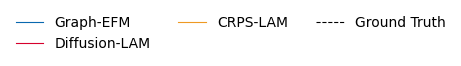

In [4]:
# Potentially plot legend separately
from matplotlib.lines import Line2D

# Create Line2D objects for each model
lines = []
base_colors = {
    "Graph-EFM": "#0968af",
    "Diffusion-LAM": "#d6002d",
    "CRPS-LAM": "#ee9923",
    # "Calibrated": "#C0C0C090",
    "Ground Truth": "black",
}
line_styles = {
    "Graph-EFM": "-",
    "Diffusion-LAM": "-",
    "CRPS-LAM": "-",
    # "Calibrated": "--",
    "Ground Truth": "--",
}
linewidth = 0.8  # Same as in your plot_energy_spectra function

# Create a Line2D object for each model
for model_name, color in base_colors.items():
    lines.append(
        Line2D([0], [0], 
               color=color, 
               linestyle=line_styles[model_name], 
               linewidth=linewidth,
               label=model_name)
    )

# Potentially plot legend separately
legend_entries = 3
legend_cols = 3
tue_width, tue_height = figsizes.neurips2023()["figure.figsize"]

# Make legend on separate figure
legend_width = tue_width * (
    min(legend_entries, legend_cols) / legend_cols
)
legend_height = 0.2 * (legend_entries // legend_cols)
legend_fig, legend_ax = plt.subplots(
    figsize=(legend_width, legend_height)
)
legend_artist = legend_ax.legend(
    handles=lines,
    bbox_to_anchor=(0, 0, 1, 1),
    bbox_transform=legend_fig.transFigure,
    frameon=False,
    fancybox=None,
    shadow=False,
    ncol=min(legend_cols, legend_entries),
    # mode="expand",
    loc="center"
)
legend_ax.axis("off")

# Save legend
legend_fig.savefig(
    os.path.join(f"rmse_legend.pdf"),
    bbox_inches="tight",
    bbox_extra_artists=[legend_artist],
)

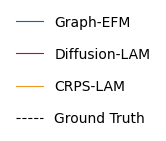

In [5]:
# Column Legend
# Potentially plot legend separately
from matplotlib.lines import Line2D

# Create Line2D objects for each model
lines = []
base_colors = {
    "Graph-EFM": "#0968af",
    "Diffusion-LAM": "#d6002d",
    "CRPS-LAM": "#ee9923",
    # "Calibrated": "#C0C0C090",
    "Ground Truth": "black",
}
line_styles = {
    "Graph-EFM": "-",
    "Diffusion-LAM": "-",
    "CRPS-LAM": "-",
    # "Calibrated": "--",
    "Ground Truth": "--",
}
linewidth = 0.8  # Same as in your plot_energy_spectra function

# Create a Line2D object for each model
for model_name, color in base_colors.items():
    lines.append(
        Line2D([0], [0], 
               color=color, 
               linestyle=line_styles[model_name], 
               linewidth=linewidth,
               label=model_name)
    )

# Potentially plot legend separately
legend_entries = len(lines)
tue_width, tue_height = figsizes.neurips2023()["figure.figsize"]

# Make legend on separate figure with 1 column (vertical stack)
legend_width = tue_width * 0.3  # Adjust width as needed for vertical layout
legend_height = 0.15 * legend_entries  # More height for vertical layout
legend_fig, legend_ax = plt.subplots(
    figsize=(legend_width, legend_height)
)
legend_artist = legend_ax.legend(
    handles=lines,
    bbox_to_anchor=(0, 0, 1, 1),
    bbox_transform=legend_fig.transFigure,
    frameon=False,
    fancybox=None,
    shadow=False,
    ncol=1,  # Set to 1 for a single column (vertical stack)
    loc="center",
    labelspacing=1.3,  # Increase spacing between entries
)
legend_ax.axis("off")

# Save legend
legend_fig.savefig(
    os.path.join(f"spectra_legend_column.pdf"),
    bbox_inches="tight",
    bbox_extra_artists=[legend_artist],
)

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
/tmp/ipykernel_3695669/1375938889.py:224: UserWarning: The figure layout has changed to tight
  plt.

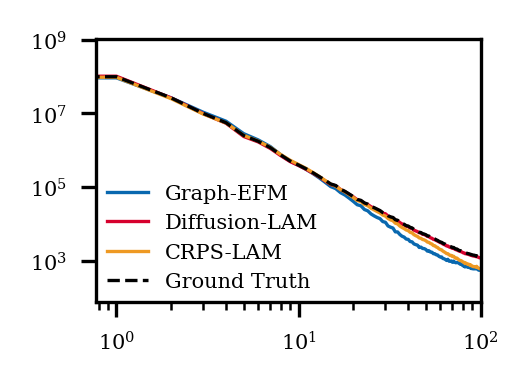

In [54]:
# Plot spectra for specific variable and lead time
fig = plot_energy_spectra(models_data["prob_hi"]["predictions"]["target"], models_data, 4, 18, show_legend=True, title=None, show_title=False)
fig.savefig(f"r_2_paper_19.pdf", bbox_inches="tight", dpi=300)
# Wavenumber (1/10 km)
# 1 / (1/10) -> km spacing, Wavelength (km) --> Vända på x-axeln. (10^3 -> 10^1, cutoff.)
# Subsample data, fjärde grid-punkt, ingen lowpass filter

findfont: Generic family 'serif' not found because none of the following families were found: Times


/tmp/ipykernel_3695669/1399348451.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


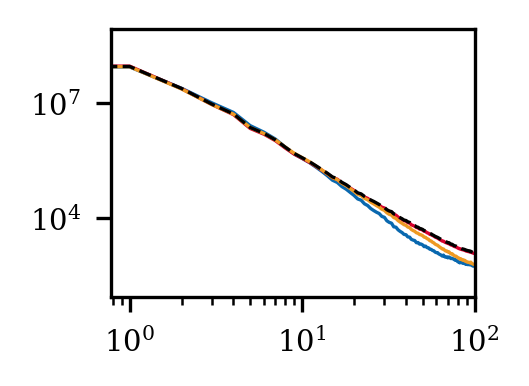

In [7]:
# Plot spectra averaged over lead time for all variables
fig = plot_energy_spectra(models_data["prob_hi"]["predictions"]["target"], models_data, 4, None, show_title=False, show_legend=False)

findfont: Generic family 'serif' not found because none of the following families were found: Times
/tmp/ipykernel_3695669/1399348451.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


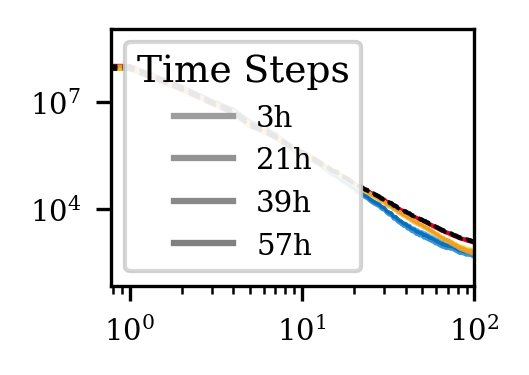

In [8]:
# Plot spectra for multiple lead times in the same plot
fig = plot_energy_spectra(models_data["prob_hi"]["predictions"]["target"], models_data, 4, [0,6,12,18], show_title=False, show_legend=False)

findfont: Generic family 'serif' not found because none of the following families were found: Times
/tmp/ipykernel_3695669/1399348451.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'serif' not found because none of the following families were found: Times
/tmp/ipykernel_3695669/1399348451.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'serif' not found because none of the following families were found: Times
/tmp/ipykernel_3695669/1399348451.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'serif' not found because none of the following families were found: Times
/tmp/ipykernel_3695669/1399348451.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'serif' not found because none of the following families were found: Times
/tmp/ipykernel_3695669/1399348451.py:217

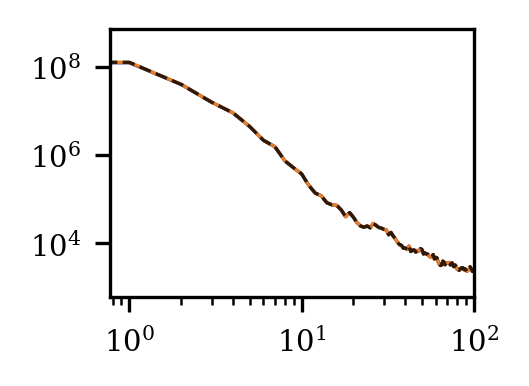

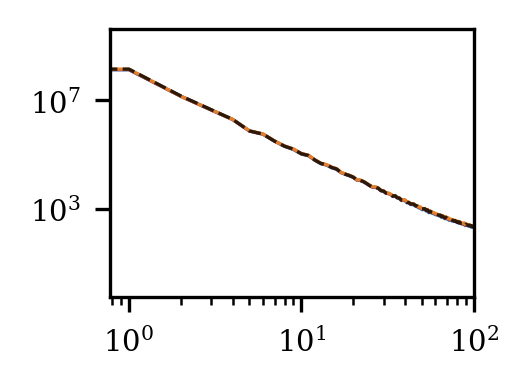

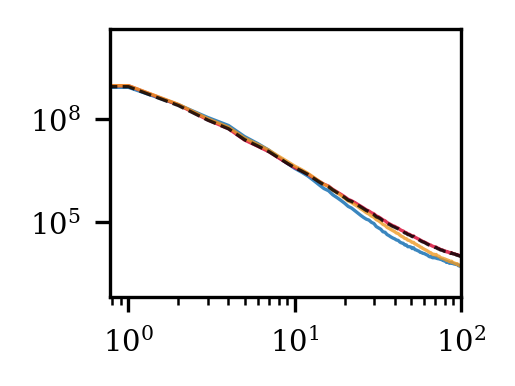

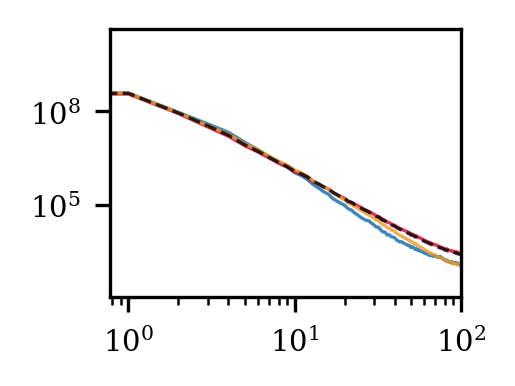

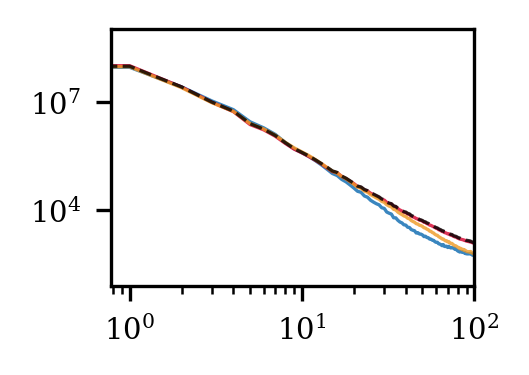

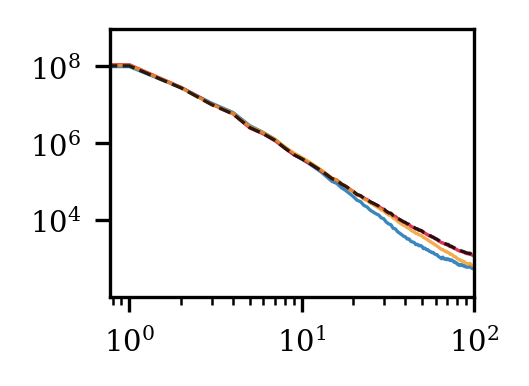

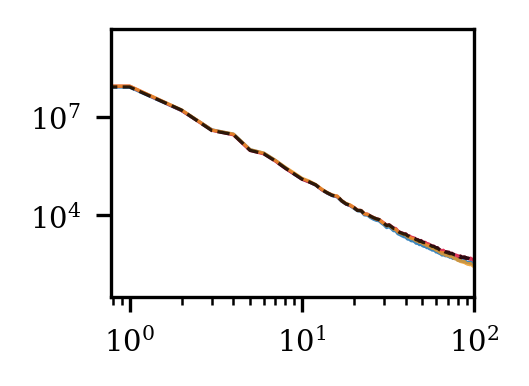

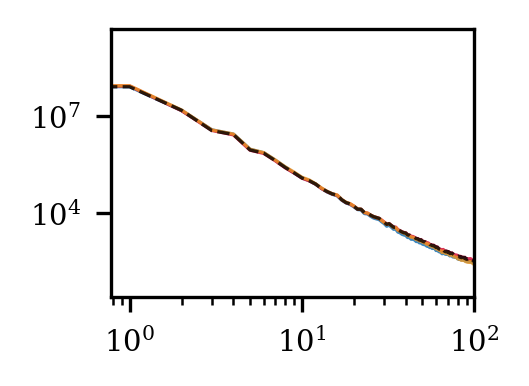

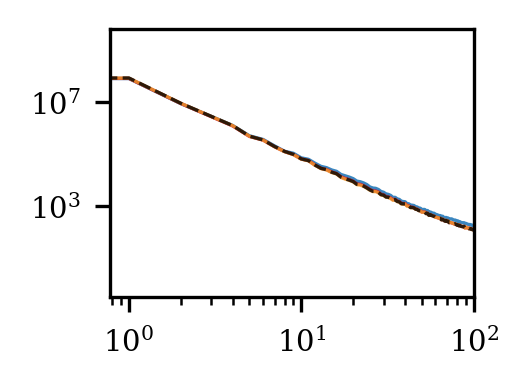

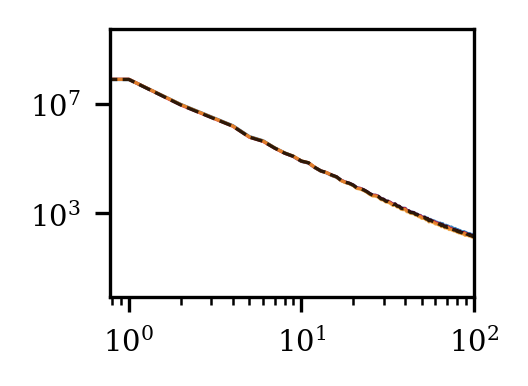

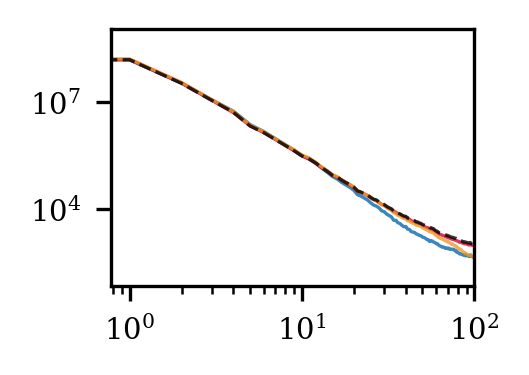

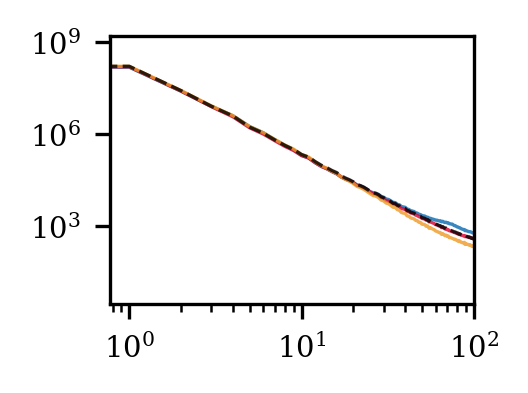

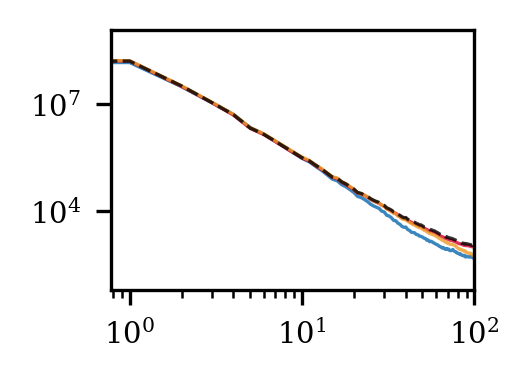

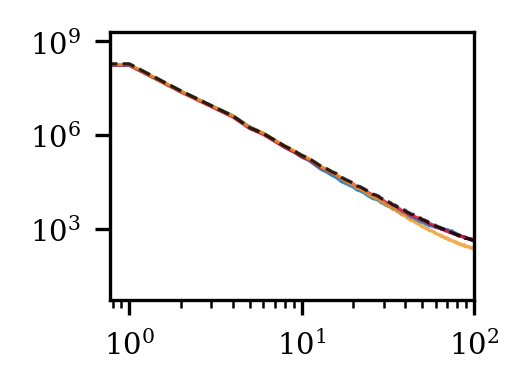

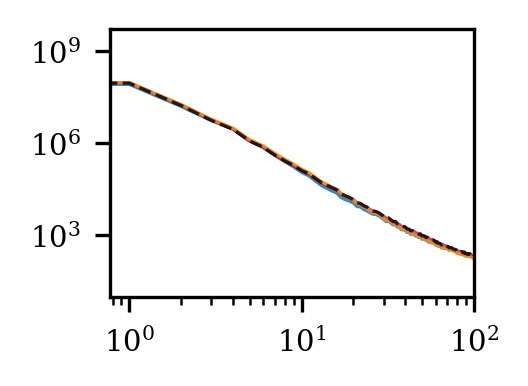

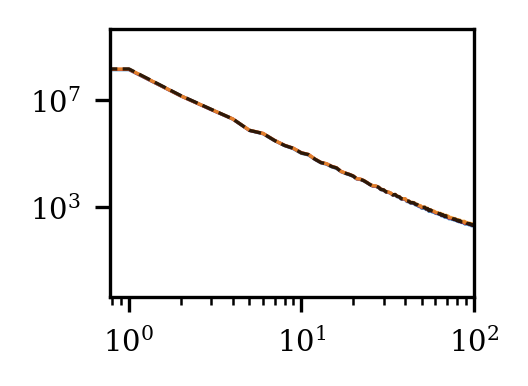

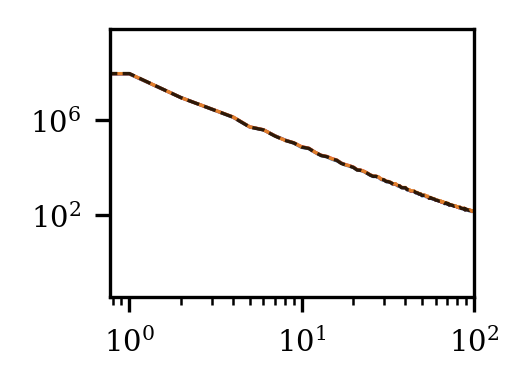

In [9]:
# Save plots
for var_idx in range(17):
    fig = plot_energy_spectra(models_data["prob_hi"]["predictions"]["target"], models_data, var_idx, [18], show_title=False, title=None, show_legend=False)
    var_name = constants.PARAM_NAMES_SHORT[constants.USED_PARAMS][var_idx]
    fig.savefig(f"{output_path}/{var_name}_19.pdf", bbox_inches="tight", dpi=300)

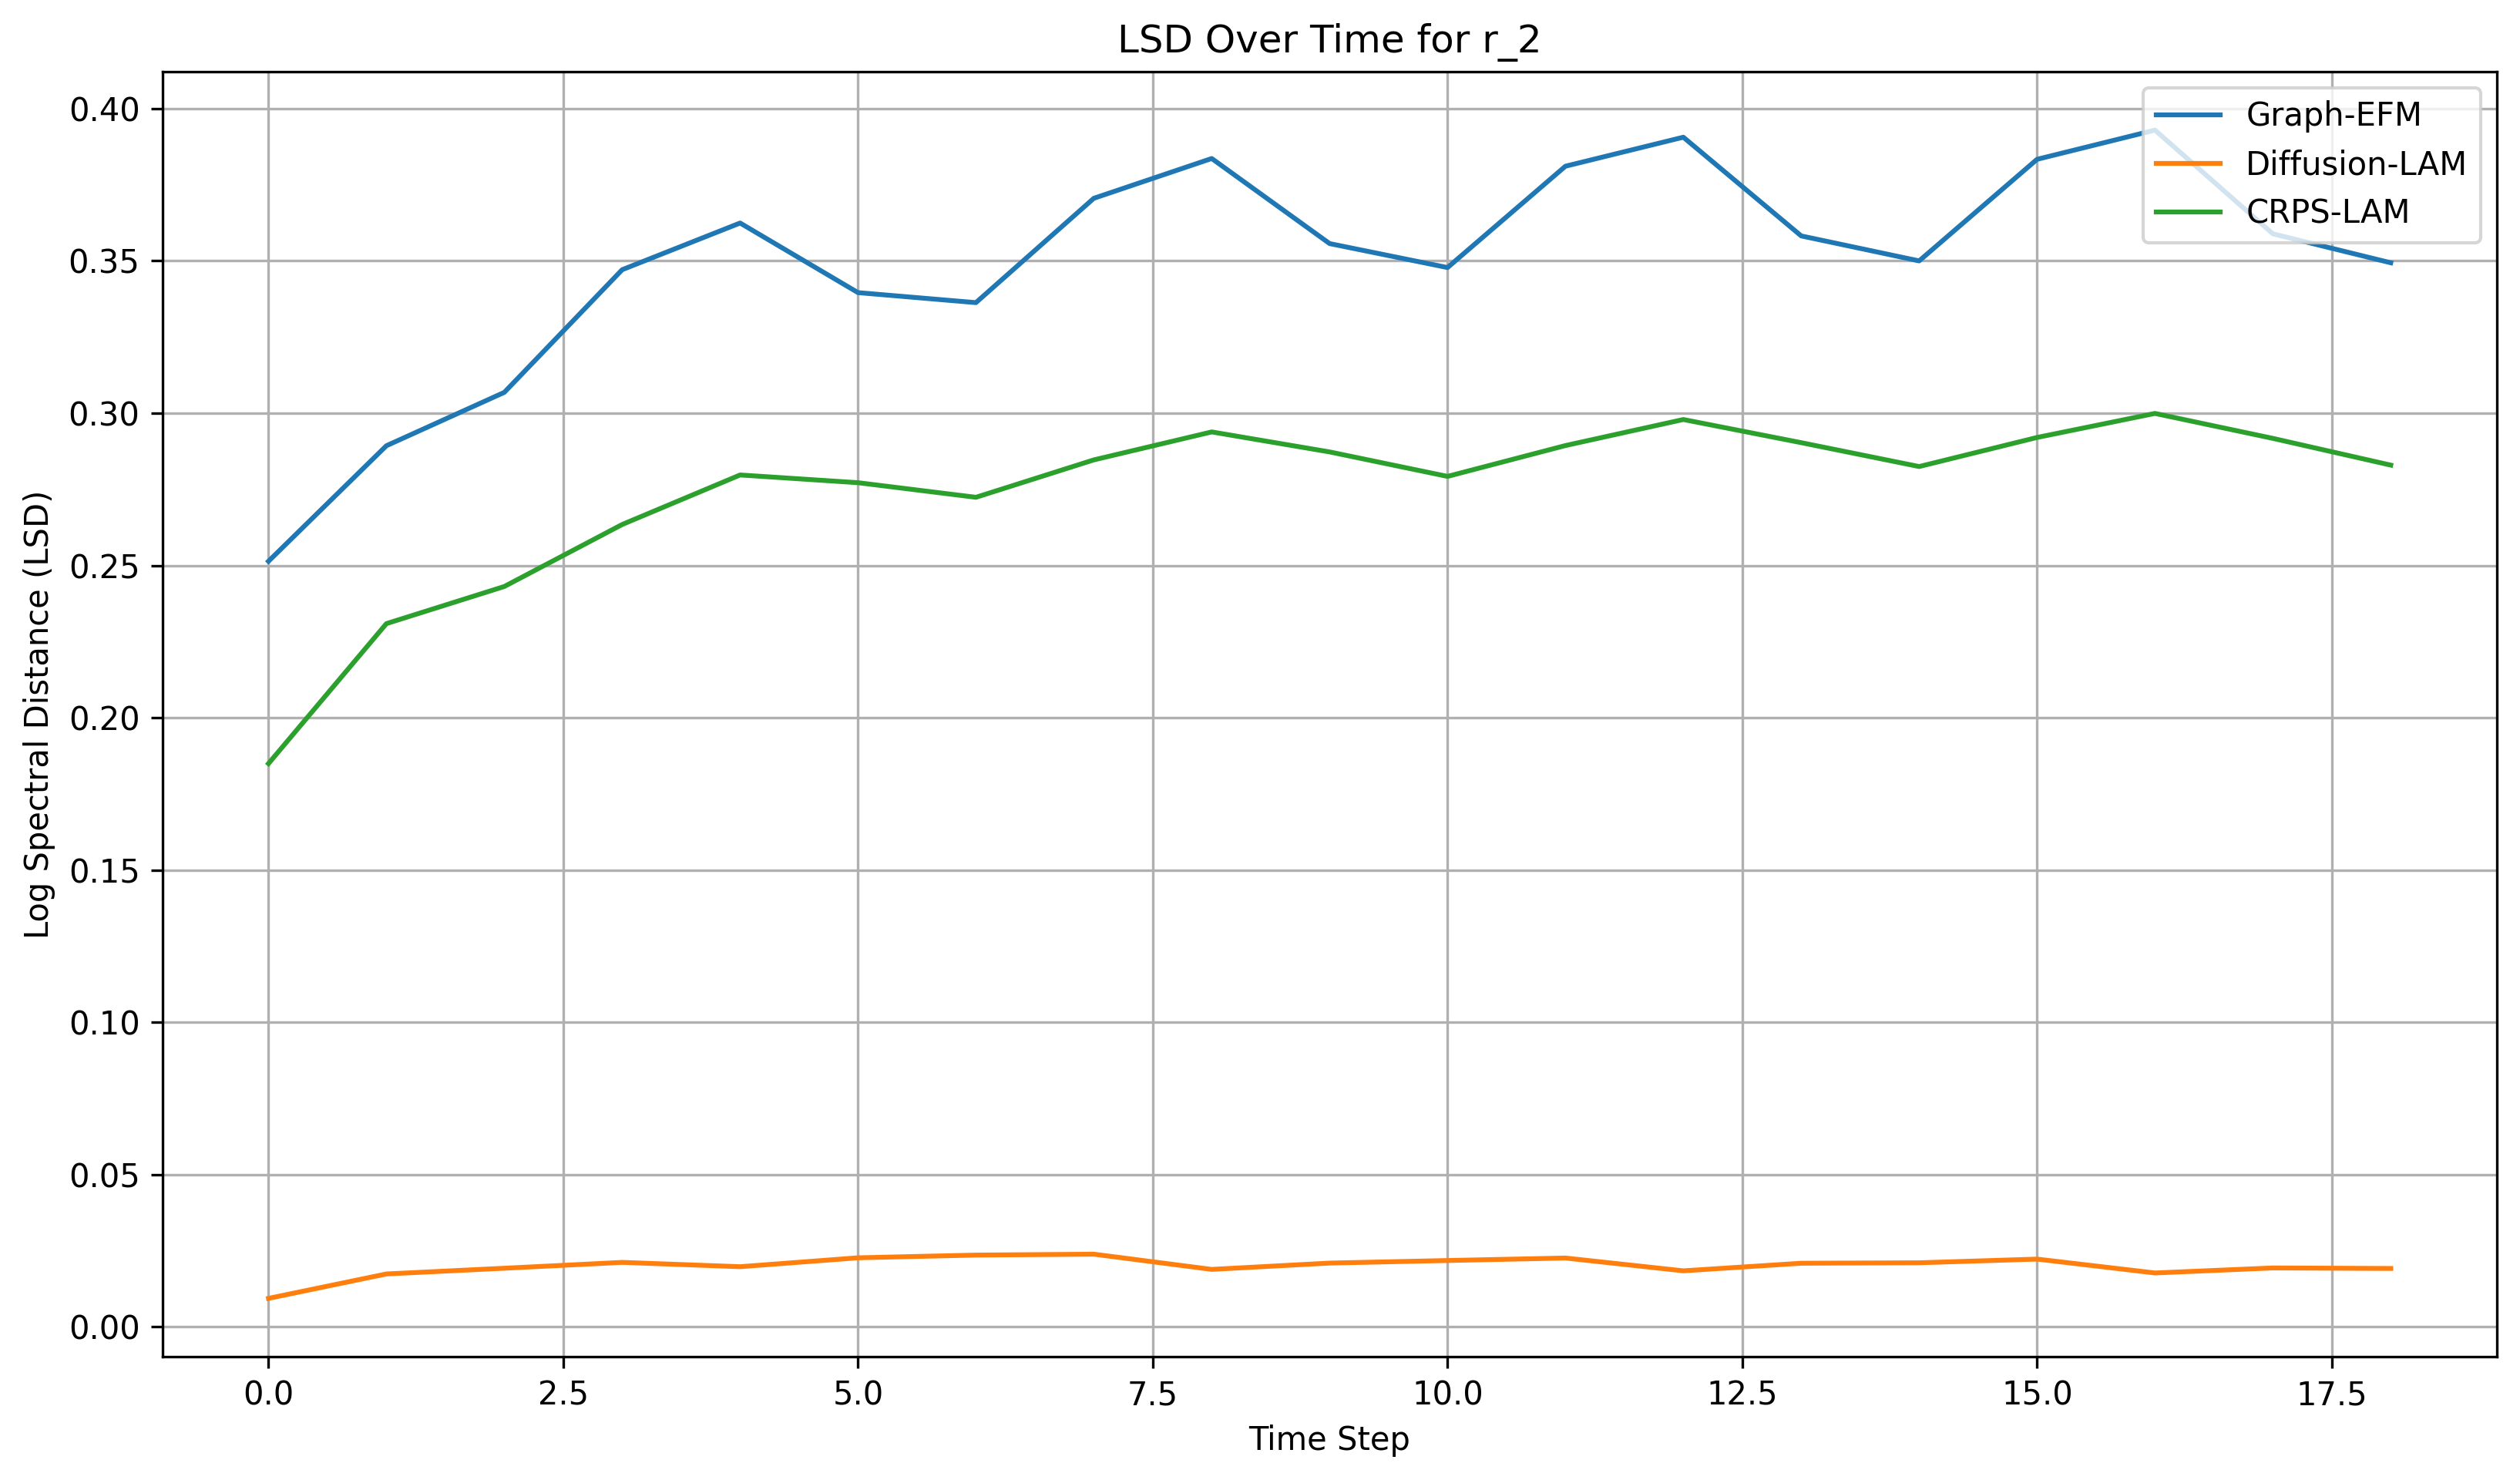

In [10]:
def plot_lsd_over_time(spectra_gt, model_lookup, var=None):
    """Plot Log Spectral Distance (LSD) over time.
    
    Parameters:
    -----------
    spectra_gt : torch.Tensor
        Ground truth spectra with shape [time_steps, variables, spectra_bins]
    model_lookup : dict
        Dictionary of model data
    var : int, optional
        Variable index to plot. If None, averages across all variables.
    """
    fig, ax = plt.subplots(figsize=(11, 6.5), dpi=300)
    time_steps = spectra_gt.shape[0]
    lsd_values = {key: [] for key in model_lookup.keys()}

    if var is not None:
        # Single variable case
        for t in range(time_steps):
            true_spectrum = spectra_gt[t, var, :].cpu().numpy()
            for key, model in model_lookup.items():
                ml_spectrum = model["predictions"]["predictions"][t, var, :].cpu().numpy()
                lsd_ml = metrics.calculate_log_spectral_distance(true_spectrum, ml_spectrum)
                lsd_values[key].append(lsd_ml)
                
        title_suffix = f"for {constants.PARAM_NAMES_SHORT[constants.USED_PARAMS][var]}"
    else:
        # Average across all variables
        num_vars = spectra_gt.shape[1]
        for t in range(time_steps):
            for key, model in model_lookup.items():
                var_lsds = []
                for v in range(num_vars):
                    true_spectrum = spectra_gt[t, v, :].cpu().numpy()
                    ml_spectrum = model["predictions"]["predictions"][t, v, :].cpu().numpy()
                    lsd = metrics.calculate_log_spectral_distance(true_spectrum, ml_spectrum)
                    var_lsds.append(lsd)
                # Average LSD across all variables
                avg_lsd = np.mean(var_lsds)
                lsd_values[key].append(avg_lsd)
                
        title_suffix = "averaged across all variables"

    # Plot LSD values over time for each model
    for key, lsd_list in lsd_values.items():
        ax.plot(range(time_steps), lsd_list, label=model_lookup[key]["model_name"])

    # Customize plot
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Log Spectral Distance (LSD)")
    ax.set_title(f"LSD Over Time {title_suffix}")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()

    return fig

fig_lsd = plot_lsd_over_time(models_data["prob_hi"]["predictions"]["target"], models_data, 4)

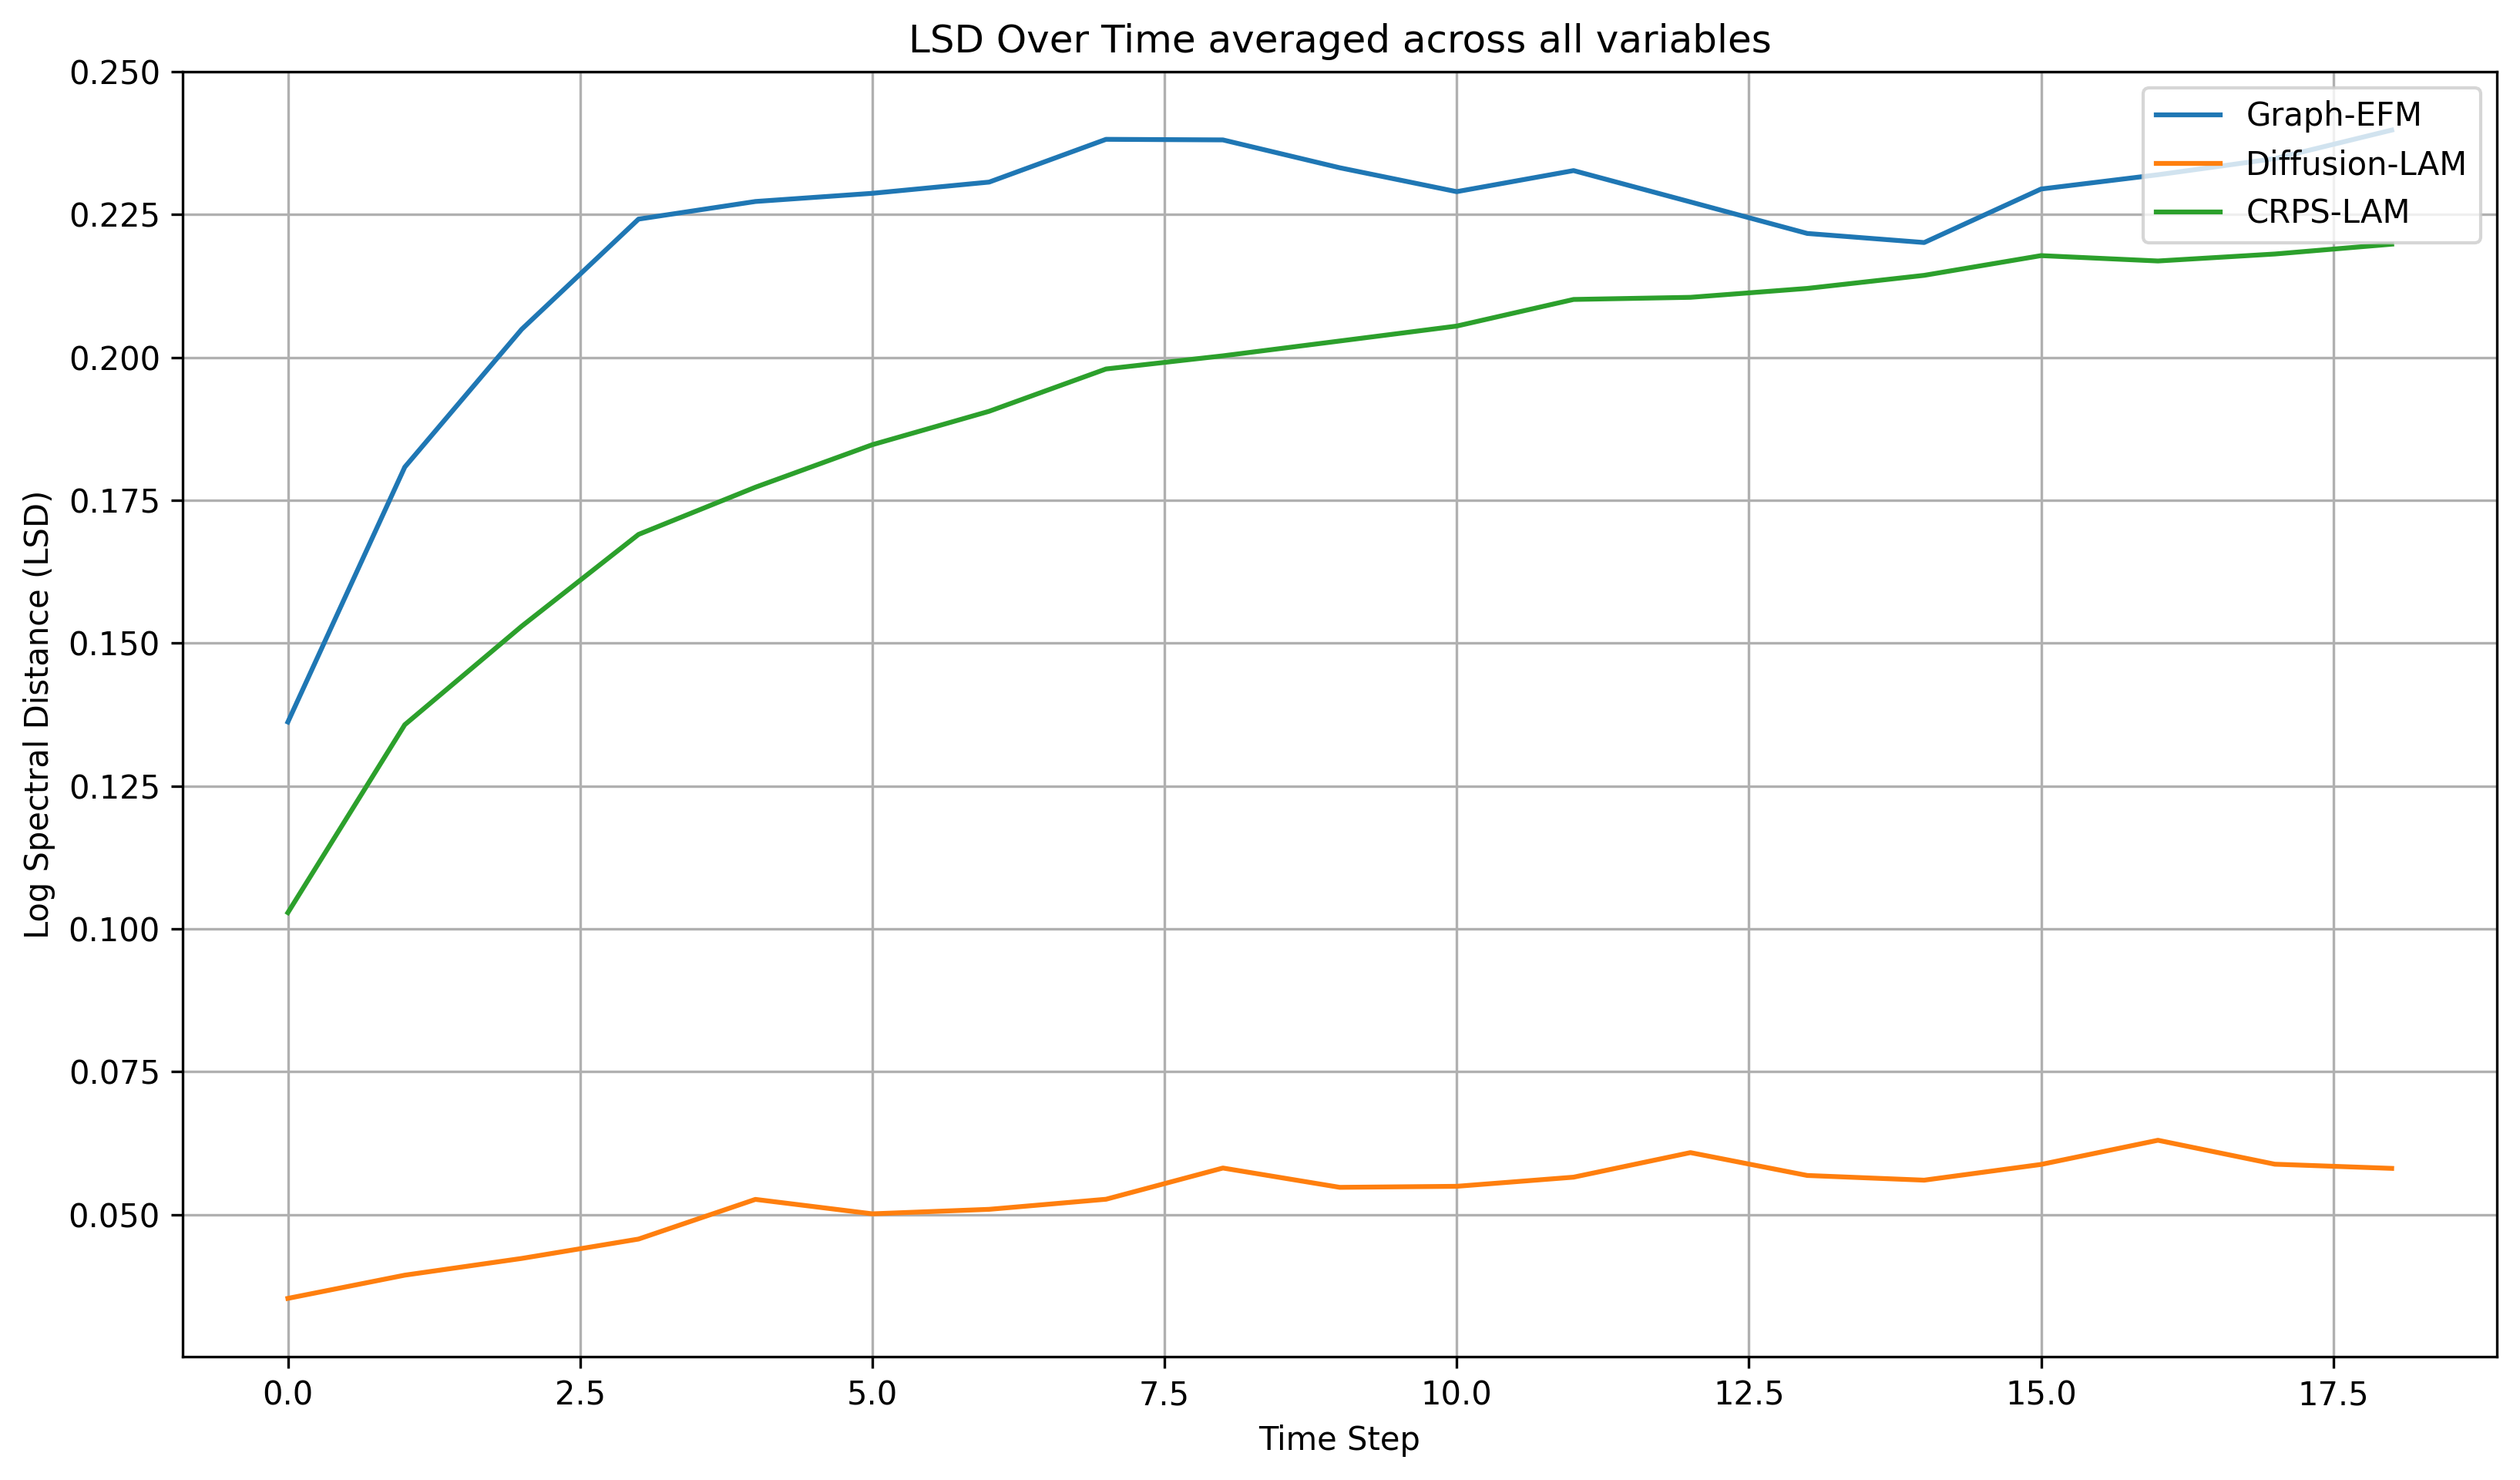

In [11]:
# Plot LSD over time averaged over all variable
fig_lsd = plot_lsd_over_time(models_data["diff"]["predictions"]["target"], models_data, None)